IMPORTS
-

In [85]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

In [2]:
df = pd.read_csv("../data/spam_mail.csv")

In [4]:
df.head(10)

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


----
RENAMING COLUMNS

----

In [6]:
df.rename(columns={'Masseges':"messages","Category":"category"},inplace=True)

In [7]:
df.head(10)

,category,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


FEATURE ENGINEERING 
--

In [15]:
def extract_numericFeature(text):
    return pd.Series({
        "length":len(text),
        "num_digits" : sum(char.isdigit() for char in text),
        "caps_ratio" : (sum(char.isupper() for char in text)) / (len(text)+1),
        "num_links" : len(re.findall("https|www",text))
    })

numeric_features = df['messages'].apply(extract_numericFeature)

In [16]:
print(numeric_features)

      length  num_digits  caps_ratio  num_links
0      111.0         0.0    0.026786        0.0
1       29.0         0.0    0.066667        0.0
2      155.0        25.0    0.064103        0.0
3       49.0         0.0    0.040000        0.0
4       61.0         0.0    0.032258        0.0
...      ...         ...         ...        ...
5567   161.0        21.0    0.055556        0.0
5568    37.0         0.0    0.052632        0.0
5569    57.0         0.0    0.034483        0.0
5570   125.0         0.0    0.015873        0.0
5571    26.0         0.0    0.074074        0.0

[5572 rows x 4 columns]


----
AFTER FEATURE ENGINEERING

----

In [19]:
df_fe = pd.concat([df.reset_index(drop = True),numeric_features],axis = 1)
df_fe.head(10)

,category,messages,length,num_digits,caps_ratio,num_links
0,ham,"Go until jurong point, crazy.. Available only ...",111.0,0.0,0.026786,0.0
1,ham,Ok lar... Joking wif u oni...,29.0,0.0,0.066667,0.0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155.0,25.0,0.064103,0.0
3,ham,U dun say so early hor... U c already then say...,49.0,0.0,0.040000,0.0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61.0,0.0,0.032258,0.0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,148.0,4.0,0.046980,0.0
6,ham,Even my brother is not like to speak with me. ...,77.0,0.0,0.025641,0.0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,160.0,1.0,0.062112,0.0
8,spam,WINNER!! As a valued network customer you have...,158.0,19.0,0.075472,0.0
9,spam,Had your mobile 11 months or more? U R entitle...,154.0,13.0,0.090323,0.0


TRAIN TEST SPLIT
-

In [161]:
x = df_fe.drop(columns=['category'])
y = df_fe['category']
y = y.map({'ham':0,'spam':1})

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y   
)

----
DATA VISUALISATION
-
----

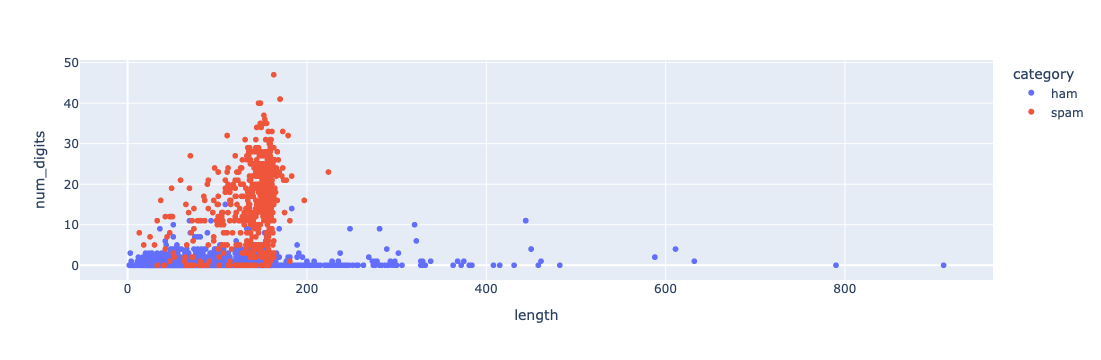

In [42]:
fig = px.scatter(
    df_fe,
    x='length',
    y='num_digits',
    color = 'category'
)
fig.show()

SPAM MAILS HAVE A LENGTH < 200 AND MAILS HAVING NUM_DIGITS > 5 ARE MAXIMUM SPAM

----
TRAINING NEURAL NETWORK 
-

----

In [72]:
from sklearn.neural_network import MLPClassifier

In [73]:
model = MLPClassifier(
    hidden_layer_sizes= (130,),
    activation = 'relu',
    max_iter = 300,
    random_state = 42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text',TfidfVectorizer(
            stop_words = 'english',
            max_df = 0.95
        ),'messages'),
        ('nums',StandardScaler(),['num_digits','length','caps_ratio','num_links'])
    ]
)

pipe = Pipeline([
    ('preprocess',preprocessor),
    ('model',model)
])

pipe.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  stop_words='english'),
                                                  'messages'),
                                                 ('nums', StandardScaler(),
                                                  ['num_digits', 'length',
                                                   'caps_ratio',
                                                   'num_links'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(130,), max_iter=300,
                               random_state=42))])

In [74]:
nn_pred = pipe.predict(x_test)

In [80]:
precision = precision_score(y_test,nn_pred)
recall = recall_score(y_test, nn_pred)
print(precision,recall)

0.9928057553956835 0.9261744966442953


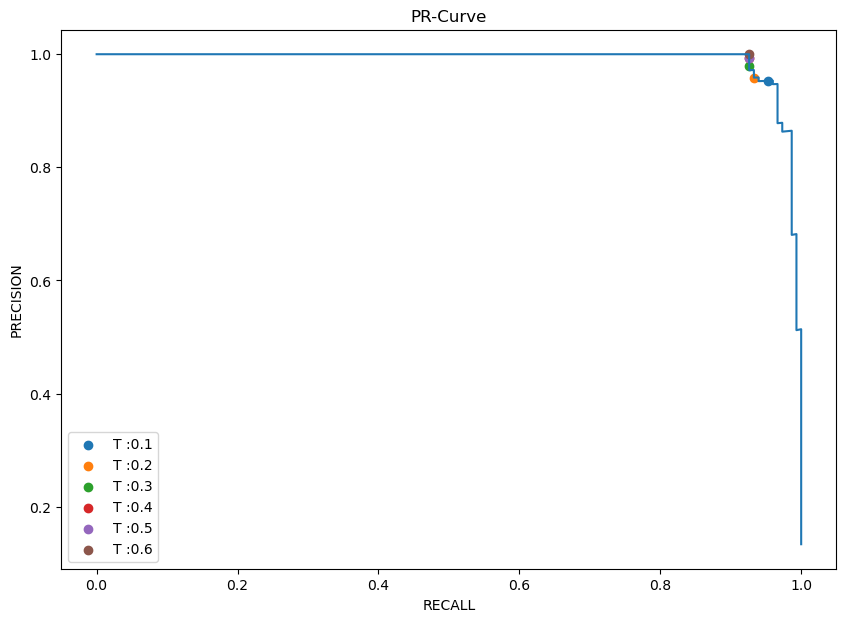

In [93]:
nn_pred_prob = pipe.predict_proba(x_test)
precision_prob, recall_prob, threshold = precision_recall_curve(y_test,nn_pred_prob[:,1])

plt.figure(figsize=(10,7))
plt.plot(recall_prob,precision_prob)
plt.xlabel("RECALL")
plt.ylabel("PRECISION")
for t in [0.1,0.2,0.3,0.4,0.5,0.6]:
    indx = (threshold >=t).argmax()
    plt.scatter(recall_prob[indx],precision_prob[indx],label = f"T :{t}")
plt.legend()
plt.title("PR-Curve")
plt.show()
    

CONFUSTION MATRIX WITH THREHSOLD
-

In [164]:
nn_pred_prob_after_threshold = (nn_pred_prob[:,1]>=0.12).astype(int)
nn_pred_prob_after_threshold

# here i choose threshold as 0.12 because it meets my requirement of precision of 99% and recall of over 90% 

array([0, 0, 0, ..., 0, 0, 0])

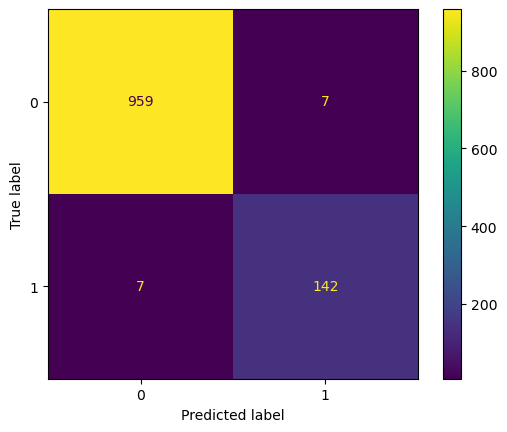

In [165]:
cm = confusion_matrix(y_test, nn_pred_prob_after_threshold)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

MISCLASSIFIED EXAMPLES
-

In [140]:
mis_indx = np.where(nn_pred_prob_after_threshold != y_test)[0]
mis_indx.size

14

In [159]:
for i in mis_indx:
    print(f"Message : {x_test.iloc[i]['messages']}\nPredicted : {nn_pred_prob_after_threshold[i]} | {nn_pred_prob[i,1]}\nTrue : {y_test.iloc[i]}\n{'--'*69}")
    

Message : ringtoneking 84484
Predicted : 0 | 0.06747133073827248
True : 1
------------------------------------------------------------------------------------------------------------------------------------------
Message : Latest News! Police station toilet stolen, cops have nothing to go on!
Predicted : 0 | 0.0018179209520694968
True : 1
------------------------------------------------------------------------------------------------------------------------------------------
Message : MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
Predicted : 1 | 0.377363515583737
True : 0
------------------------------------------------------------------------------------------------------------------------------------------
Message : This is ur face test ( 1 2 3 4 5 6 7 8 9  &lt;#&gt;  ) select any number i will tell ur face astrology.... am waiting. quick reply...
Predicted : 1 | 0.21397182171595766
True : 0
---------------------------------------------------------------------------------------